Of the three metrics, my portion is to analyze the amount of farmers markets and farm stands in neighborhoods in Allegheny County. The "best" neighborhood for foodies being the one with the most farmer markets and stands.

In [15]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point

# Load data
fm = pd.read_csv("farmers_markets.csv")
gardens = pd.read_csv("grow-pgh-food-gardens.csv")
neighborhoods = gpd.read_file("neighborhoods.geojson")

**Spatial Join**

In [16]:
def map_to_neighborhood_spatial(df, neighborhoods_gdf):
    df_pgh = df[df['city'].astype(str).str.strip().str.title() == "Pittsburgh"].copy()
    
    df_pgh = df_pgh.dropna(subset=['longitude', 'latitude'])
    gdf = gpd.GeoDataFrame(
        df_pgh, 
        geometry=gpd.points_from_xy(df_pgh.longitude, df_pgh.latitude)
    )
    
    gdf.crs = "EPSG:4326"
    neighborhoods_gdf = neighborhoods_gdf.to_crs("EPSG:4326")
    joined = gpd.sjoin(gdf, neighborhoods_gdf, how="left", predicate="within")
    
    return joined

**Combining Markets and Stands**

In [17]:
fm_pgh = map_to_neighborhood_spatial(fm, neighborhoods)
gardens_pgh = map_to_neighborhood_spatial(gardens, neighborhoods)

combined_neighborhoods = pd.concat([fm_pgh['hood'], gardens_pgh['hood']])
neighborhood_count = combined_neighborhoods.value_counts()

**Visualizing data**

In [18]:
print("Top 10 Pittsburgh Neighborhoods by Total Farmers Markets and Gardens (Spatial Join Method):")
print(neighborhood_count.head(10))

Top 10 Pittsburgh Neighborhoods by Total Farmers Markets and Gardens (Spatial Join Method):
hood
East Liberty             6
Garfield                 5
Point Breeze             4
South Side Flats         3
Squirrel Hill South      3
Bloomfield               3
Hazelwood                3
Larimer                  3
Central Lawrenceville    3
South Oakland            3
Name: count, dtype: int64


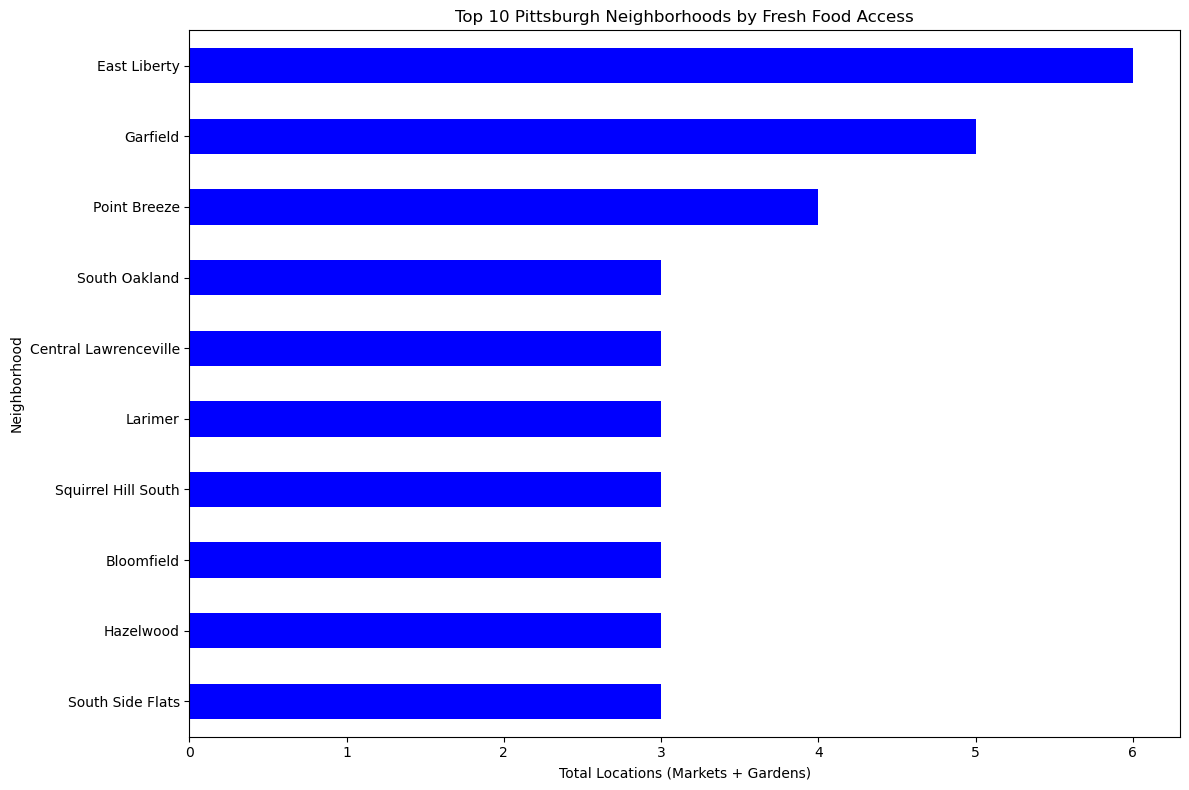

In [19]:
plt.figure(figsize=(12, 8))
neighborhood_count.head(10).sort_values(ascending=True).plot(kind='barh', color='blue')
plt.title('Top 10 Pittsburgh Neighborhoods by Fresh Food Access')
plt.xlabel('Total Locations (Markets + Gardens)')
plt.ylabel('Neighborhood')
plt.tight_layout()
plt.show()

In [20]:
best_neighborhood = neighborhood_count.idxmax()
print(f"The best neighborhood is {best_neighborhood} with {neighborhood_count.max()} locations.")

The best neighborhood is East Liberty with 6 locations.


**Conclusion** Based on the spatial join analysis of farmer markets and stands, East Liberty remains the top neighborhood for fresh food access. Using a spatial join ensures that locations are attributed to neighborhoods based on actual boundary polygons rather than just proximity to a single center point, providing a more accurate reflection of urban food resource distribution.